In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sys
import os
import re
from collections import Counter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.load_data import load_and_preprocess_data

In [33]:
# Load the BERT-classified data using the custom src function
file_path = 'data/NEISS_Final_Classified.csv'
print(f"Loading classified data from {file_path}...")
df = load_and_preprocess_data(file_path)

Loading classified data from data/NEISS_Final_Classified.csv...
Loading data from data/NEISS_Final_Classified.csv...
Loaded 91355 rows.


# Check

In [34]:
def get_word_freq(text_series):
    """
    Extracts word frequencies from a pandas Series of text narratives.
    Filters out words shorter than 3 characters.
    """
    # Drop NaNs, convert to string, uppercase, and join into a single giant string
    all_text = ' '.join(text_series.dropna().astype(str)).upper()
    
    # Extract only strictly alphabetic words with 3 or more characters
    words = re.findall(r'\b[A-Z]{3,}\b', all_text)
    
    counter = Counter(words)
    total = sum(counter.values())
    
    # Calculate relative frequencies
    freqs = {w: c / total for w, c in counter.items()} if total > 0 else {}
    
    return freqs, counter


def analyze_bert_word_frequencies(df, text_col='Narrative', pred_col='bert_prediction'):
    """
    Analyzes word frequencies to interpret which words the BERT model 
    strongly associates with the positive class (Vitamins) vs the negative class.
    Provides Explainable AI (XAI) insights into the model's decision boundaries.
    """
    print(f"Analyzing word distributions based on '{pred_col}' classifications...")
    
    # Ensure predictions are evaluated as integers to avoid dtype mismatch
    df[pred_col] = df[pred_col].astype(int)
    
    # Calculate word counts for predicted Vitamins (1) and Other Exposures (0)
    freq1, counts1 = get_word_freq(df[df[pred_col] == 1][text_col])
    freq0, counts0 = get_word_freq(df[df[pred_col] == 0][text_col])
    
    print(f"Predicted Vitamins (1) total tokens: {sum(counts1.values())}")
    print(f"Predicted Other (0) total tokens:    {sum(counts0.values())}")

    # Discriminative score using a smoothed ratio (Laplace smoothing)
    # alpha prevents division by zero if a word only appears in class 1
    min_count = 10
    alpha = 1

    scores = []
    for word, c1 in counts1.items():
        if c1 >= min_count:
            c0 = counts0.get(word, 0)
            # Score represents how many times more likely the word appears in class 1 vs class 0
            score = (c1 + alpha) / (c0 + alpha)
            scores.append((word, c1, c0, score))

    # Sort the words by their discriminative score in descending order
    scores.sort(key=lambda x: x[3], reverse=True)
    
    print("\nTop 15 words highly predictive of a Vitamin exposure (BERT interpretation):")
    print("-" * 75)
    print(f"{'WORD'.ljust(20)} | {'VITAMIN COUNT'.ljust(15)} | {'OTHER COUNT'.ljust(15)} | {'RATIO'}")
    print("-" * 75)
    
    # Print the top 15 words with formatted columns for easy reading
    for word, c1, c0, score in scores[:15]:
        print(f"{word.ljust(20)} | {str(c1).ljust(15)} | {str(c0).ljust(15)} | {score:.2f}x")
        
    return scores

# Cast the confidence column from string to numeric (float)
df['bert_confidence'] = pd.to_numeric(df['bert_confidence'], errors='coerce')
# Apply the Calibrated Thresholding
df['strict_prediction'] = (df['bert_confidence'] > 0.995).astype(int)
scores = analyze_bert_word_frequencies(df, pred_col='strict_prediction')

Analyzing word distributions based on 'strict_prediction' classifications...
Predicted Vitamins (1) total tokens: 9604
Predicted Other (0) total tokens:    1187858

Top 15 words highly predictive of a Vitamin exposure (BERT interpretation):
---------------------------------------------------------------------------
WORD                 | VITAMIN COUNT   | OTHER COUNT     | RATIO
---------------------------------------------------------------------------
TABLETSACCIDENTAL    | 18              | 9               | 1.90x
PILLSACCIDENTAL      | 17              | 15              | 1.12x
PILLACCIDENTAL       | 13              | 24              | 0.56x
VITAMIN              | 63              | 388             | 0.16x
PRENATAL             | 18              | 138             | 0.14x
VITAMINS             | 82              | 625             | 0.13x
GUMMY                | 13              | 124             | 0.11x
BIRTH                | 14              | 139             | 0.11x
GLIPIZIDE            |

# Data Preprocessing

In [35]:
# Data preprocessing

# Convert weights to numeric (if not already handled by load_and_preprocess_data)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Filter dataset to analyze ONLY Vitamin exposures (Denominator Problem)
df = df[df['bert_confidence'] > 0.99].copy()

# Convert Treatment_Date to actual datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Drop rows with invalid dates
df = df.dropna(subset=['Year', 'Month'])

# Ensure 'Age' column is numeric, converting non-numeric values to NaN (Not a Number)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_Years'] = np.where(df['Age'] >= 200, (df['Age'] - 200) / 12, df['Age'])

# Age Grouping (<1, 1, 2, 3, 4+)
df['Age_Group'] = np.where(df['Age_Years'] < 1, '<1',
                      np.where(df['Age_Years'] < 2, '1',
                      np.where(df['Age_Years'] < 3, '2',
                      np.where(df['Age_Years'] < 4, '3', '4+'))))

# Mapping standard NEISS codes for readability in plots
sex_map = {'1': 'Male', '2': 'Female', '0': 'Unknown'}
race_map = {'1': 'White', '2': 'Black', '3': 'Other', '0': 'Unknown', np.nan: 'Unknown'}
disp_map = {'1': 'Treated/Released', '2': 'Transferred', '4': 'Admitted', '5': 'Observation', '6': 'Left AMA', '8': 'Fatality', '9': 'Unknown'}
loc_map = {'1': 'Home', '2': 'Farm', '4': 'Street/Highway', '5': 'Public Property', '8': 'School', '9': 'Sports/Recreation', '0': 'Unknown'}
fire_map = {'0': 'No Fire', '1': 'Fire Involved', '2': 'Fire Dept Attended', '3': 'Fire+Dept'}

df['Sex_Label'] = df['Sex'].map(sex_map).fillna('Unknown')
df['Race_Label'] = df['Race'].map(race_map).fillna('Unknown')
df['Disposition_Label'] = df['Disposition'].map(disp_map).fillna('Unknown')
df['Location_Label'] = df['Location'].map(loc_map).fillna('Unknown')
df['Fire_Label'] = df['Fire_Involvement'].map(fire_map).fillna('Unknown')


# YEARLY DATA
yearly_data = df.groupby('Year')['Weight'].sum()

# QUARTERLY DATA
# Create a continuous Year-Quarter column (e.g., Q1 2004, Q2 2004)
# .dt.to_period('Q') converts dates to the correct fiscal quarter
# .dt.to_timestamp() converts it back to the first day of that quarter (e.g., Jan 1st, Apr 1st) for plotting
df['YearQuarter'] = df['Treatment_Date'].dt.to_period('Q').dt.to_timestamp()
quarterly_data = df.groupby('YearQuarter')['Weight'].sum()

# INDEXED DATA (Base Year = 100)
# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()
# Divide all years by the base year's value and multiply by 100
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100

# NORMALIZED SEASONALITY CALCULATION ---
# 1) Sum total ED visits for each specific Month of each Year

# 2) Sum total ED visits for the entire Year
monthly_yearly_data = df.groupby(['Year', 'Month'])['Weight'].sum().reset_index()
yearly_totals = monthly_yearly_data.groupby('Year')['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# 3) Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on='Year')
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# 4) Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby('Month')['Month_Share_Pct'].mean()


# Temporal Analysis

#### Absolute Yearly Trend

To evaluate whether the incidence of vitamin-related ED visits has significantly changed over the 2004-2023 period, an OLS Linear Regression model is applied. The model attempts to fit the best straight line through the annual estimates.

* **Null Hypothesis ($H_0$)**: The slope of the trend line is equal to zero. This implies there is no underlying linear trend over time; the number of annual ED visits is stationary, and any observed variations are purely due to random statistical noise.
* **Alternative Hypothesis ($H_1$)**: The slope of the trend line is not equal to zero. This implies there is a statistically significant linear trend (either increasing or decreasing) in the number of ED visits over the years.

We use a standard significance level of $\alpha = 0.01$ and conclude that the trend is statistically significant.

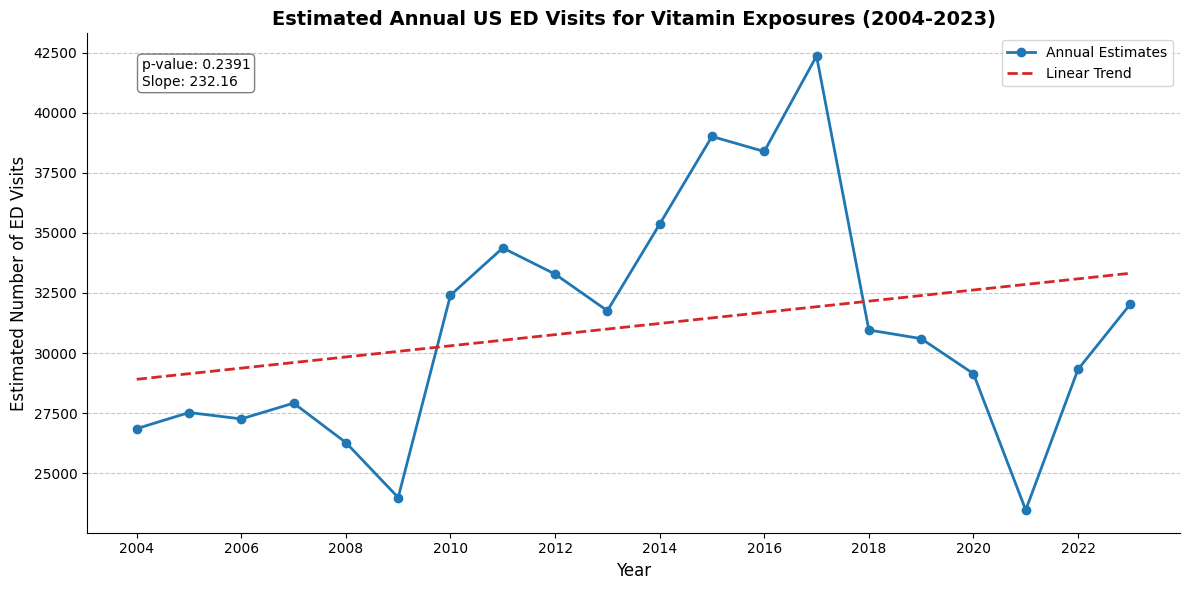

In [36]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
# Extract the p-value and the slope (coefficient) for the 'Year' variable
# model.pvalues[1] refers to the p-value of the Year coefficient
p_value = model.pvalues[1]
slope = model.params[1]
intercept = model.params[0]

# Generate predicted values for the trend line based on the regression model
trend_line = intercept + slope * yearly_data.index


plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line to visualize the overall direction
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Linear Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance (p-value)
stats_text = f'p-value: {p_value:.4f}\nSlope: {slope:.2f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

#### Quarterly Trend

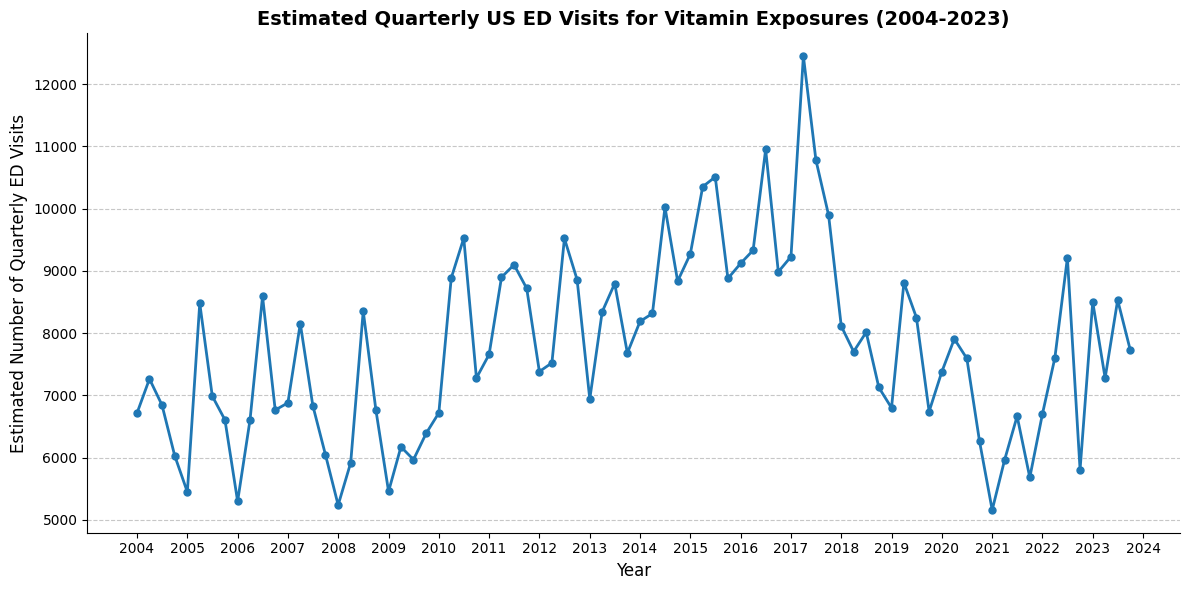

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(quarterly_data.index, quarterly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=5)

plt.title('Estimated Quarterly US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of Quarterly ED Visits', fontsize=12)

# Format the X-axis to show a tick for every single year cleanly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

#### Seasonality Analysis

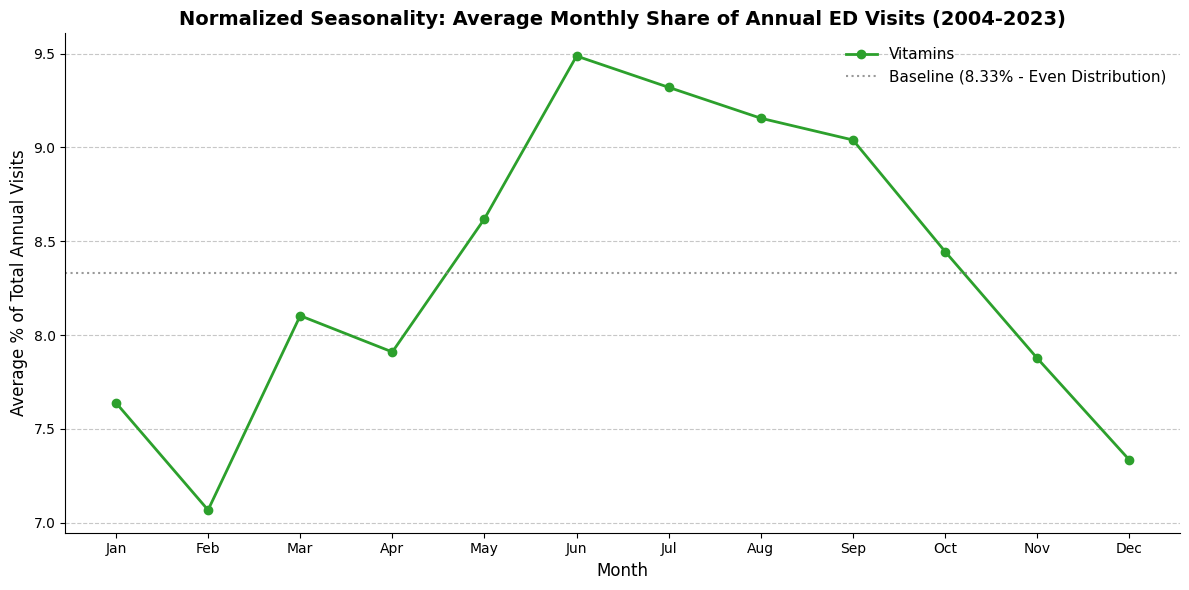

In [38]:
plt.figure(figsize=(12, 6))

# Plot Vitamins
plt.plot(final_seasonality.index, final_seasonality, 
         marker='o', color='#2ca02c', linewidth=2, label='Vitamins')


# Formatting
plt.title('Normalized Seasonality: Average Monthly Share of Annual ED Visits (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average % of Total Annual Visits', fontsize=12)

# Set X-axis to display month names properly using the 'calendar' library
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])

# Add a baseline horizontal line (100% / 12 months = 8.33%)
plt.axhline(y=100/12, color='gray', linestyle=':', alpha=0.8, 
            label='Baseline (8.33% - Even Distribution)')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Stratified Analysis


### Stratified Trend Analysis: Multivariate Linear Regression with Interaction Terms

To go beyond the global trend and understand the underlying dynamics of vitamin-related exposures, we utilized **Multivariate Ordinary Least Squares (OLS) Linear Regression models incorporating interaction terms**. 

#### Methodology
For each demographic and clinical category (Age, Sex, Race, Disposition), we modeled the estimated annual ED visits as a function of time (`Year`), the categorical variable, and the interaction between the two (`Year * Category`). 
* **Main Effect:** Accounts for the absolute baseline differences in volume between subgroups.
* **Interaction Term:** Measures whether the *slope* (the rate of growth or decline over time) for a specific subgroup is statistically different from the baseline subgroup. A significant interaction $p$-value ($p < 0.05$) indicates that the subgroup's temporal trend is diverging significantly from the baseline, allowing us to identify exactly which populations are driving the overall changes.

#### Summary of Key Findings
In a multivariate linear regression model analyzing temporal trends (2004-2023), significant interactions were observed across multiple demographic and clinical categories, highlighting a clear shift in the epidemiology of vitamin exposures:

* **Age Dynamics:** The most dramatic divergence in age trends was seen in children aged 4+. While exposures in 1-year-olds (the baseline) exhibited a slight decline over the study period, ED visits for the 4+ age group increased at a significantly steeper rate (interaction coefficient: +2851 visits/year, $p < 0.001$). 
* **Sex:** Sex showed no significant impact on the temporal trend, indicating that the shifting exposure patterns affect males and females proportionately ($p = 0.332$). 
* **Clinical Acuity (Disposition):** Crucially, analysis of patient disposition revealed that the annual growth rate of hospital admissions ('Admitted') outpaced that of less severe cases ('Treated/Released'). The negative interaction term for discharged patients relative to admitted patients indicates a statistically significant shift toward higher-acuity presentations over the 20-year study period ($p = 0.004$).

*The following code block iterates through the specified categories, fits the interaction models, and outputs the OLS summary tables containing the respective coefficients, standard errors, and $p$-values.*

--- Analyzing Category: AGE_GROUP ---


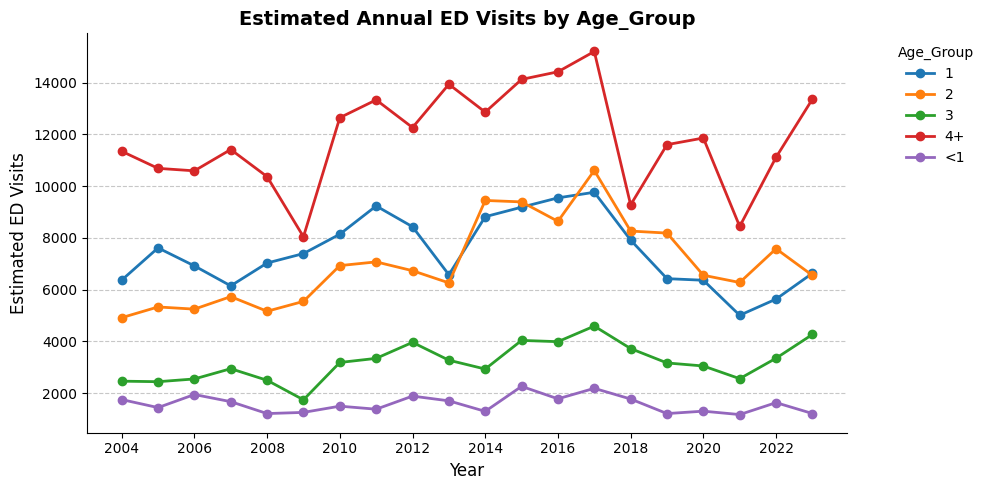

  > 1: Trend = -29.3 visits/year | p-value = 0.6263 (Not Significant)


  > 2: Trend = +148.8 visits/year | p-value = 0.0078 (SIGNIFICANT)


  > 3: Trend = +67.2 visits/year | p-value = 0.0055 (SIGNIFICANT)


  > 4+: Trend = +53.9 visits/year | p-value = 0.4360 (Not Significant)


  > <1: Trend = -8.4 visits/year | p-value = 0.4143 (Not Significant)


--- Analyzing Category: SEX ---


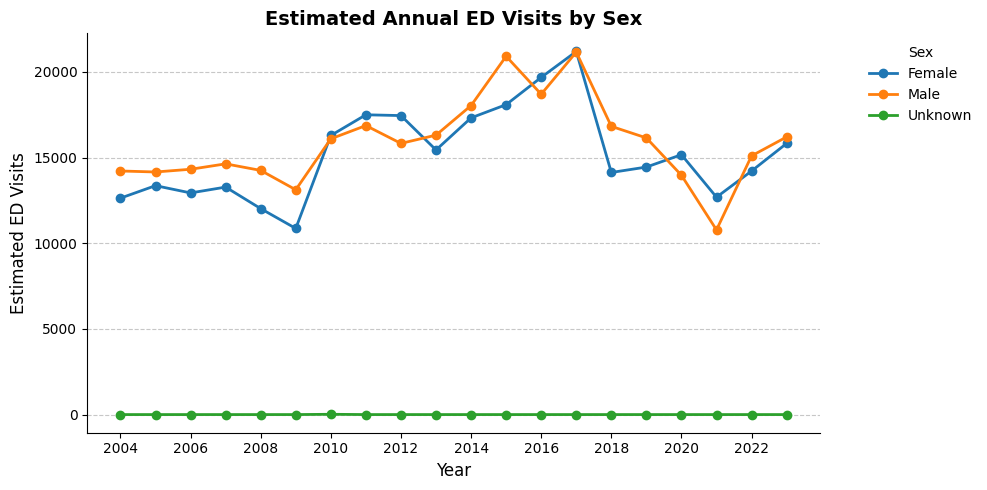

  > Female: Trend = +151.2 visits/year | p-value = 0.1200 (Not Significant)


  > Male: Trend = +81.0 visits/year | p-value = 0.4378 (Not Significant)


  > Unknown: Trend = -0.1 visits/year | p-value = 0.3474 (Not Significant)


--- Analyzing Category: RACE ---


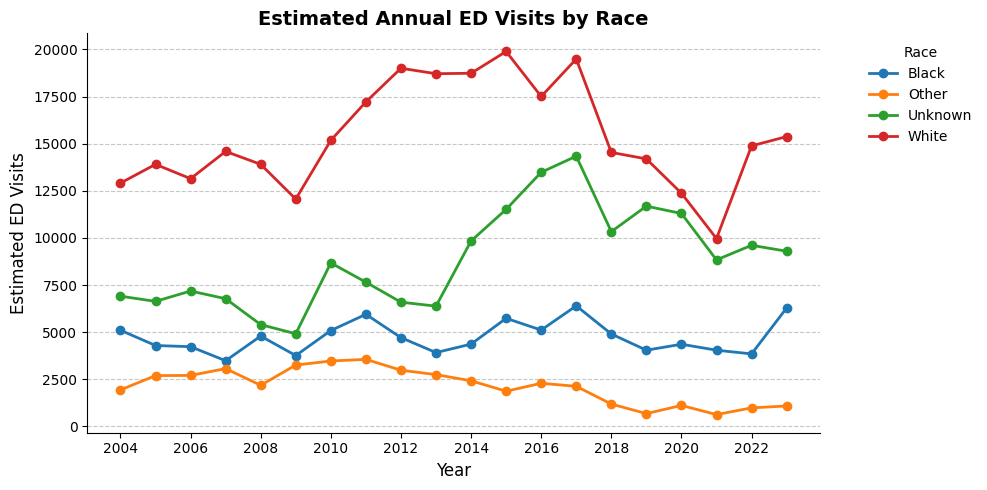

  > Black: Trend = +25.6 visits/year | p-value = 0.4254 (Not Significant)


  > Other: Trend = -117.6 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Unknown: Trend = +289.0 visits/year | p-value = 0.0002 (SIGNIFICANT)


  > White: Trend = +35.2 visits/year | p-value = 0.7571 (Not Significant)


--- Analyzing Category: DISPOSITION ---


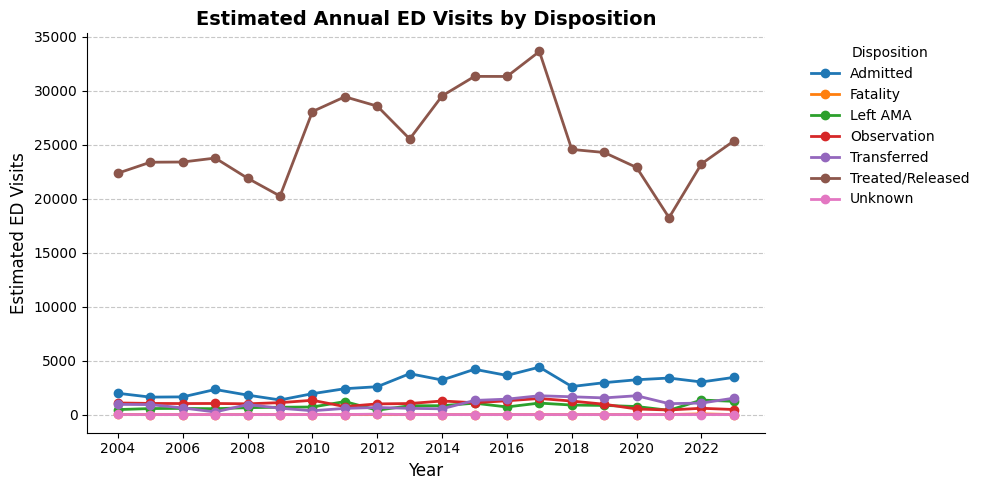

  > Admitted: Trend = +106.2 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Fatality: Trend = +0.6 visits/year | p-value = 0.4126 (Not Significant)


  > Left AMA: Trend = +25.6 visits/year | p-value = 0.0040 (SIGNIFICANT)


  > Observation: Trend = -22.2 visits/year | p-value = 0.0635 (Not Significant)


  > Transferred: Trend = +53.5 visits/year | p-value = 0.0005 (SIGNIFICANT)


  > Treated/Released: Trend = +68.6 visits/year | p-value = 0.6800 (Not Significant)


  > Unknown: Trend = -0.2 visits/year | p-value = 0.1929 (Not Significant)


--- Analyzing Category: LOCATION ---


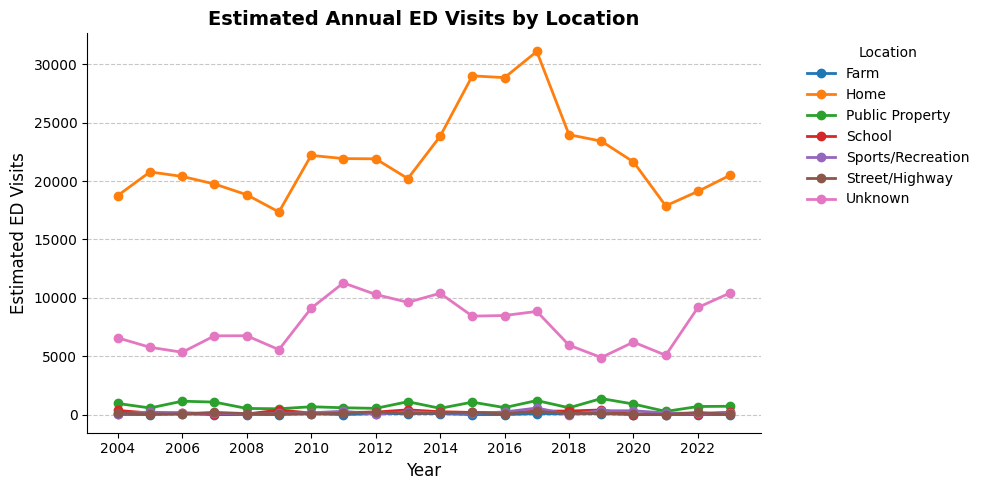

  > Farm: Trend = +0.2 visits/year | p-value = 0.8875 (Not Significant)


  > Home: Trend = +168.2 visits/year | p-value = 0.2699 (Not Significant)


  > Public Property: Trend = -2.1 visits/year | p-value = 0.8304 (Not Significant)


  > School: Trend = -1.5 visits/year | p-value = 0.7681 (Not Significant)


  > Sports/Recreation: Trend = +6.0 visits/year | p-value = 0.1054 (Not Significant)


  > Street/Highway: Trend = -0.7 visits/year | p-value = 0.7609 (Not Significant)


  > Unknown: Trend = +62.1 visits/year | p-value = 0.4674 (Not Significant)


--- Analyzing Category: FIRE INVOLVEMENT ---


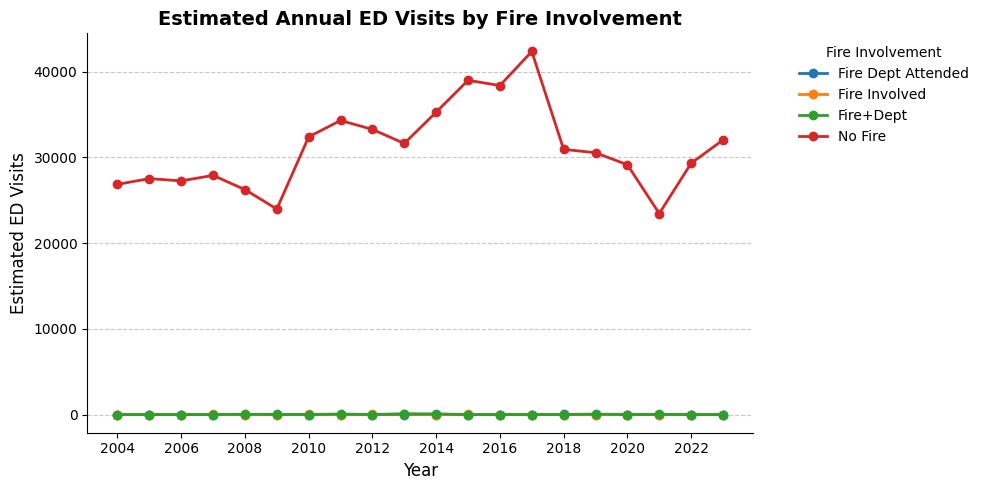

  > Fire Dept Attended: Trend = +0.1 visits/year | p-value = 0.3138 (Not Significant)


  > Fire Involved: Trend = -0.3 visits/year | p-value = 0.3023 (Not Significant)


  > Fire+Dept: Trend = +0.0 visits/year | p-value = 0.9486 (Not Significant)


  > No Fire: Trend = +232.3 visits/year | p-value = 0.2377 (Not Significant)




In [39]:
categories_to_analyze = {
    'Age_Group': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label',
    'Location': 'Location_Label',
    'Fire Involvement': 'Fire_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"--- Analyzing Category: {cat_name.upper()} ---")
    
    # Group by Year and Subcategory
    yearly_cat_data = df.groupby(['Year', col_name])['Weight'].sum().unstack(fill_value=0)
    
    # 1. PLOTTING
    plt.figure(figsize=(10, 5))
    for column in yearly_cat_data.columns:
        # Hide categories with 0 data to clean up the chart
        if yearly_cat_data[column].sum() > 0:
            plt.plot(yearly_cat_data.index, yearly_cat_data[column], marker='o', linewidth=2, label=str(column))

    plt.title(f'Estimated Annual ED Visits by {cat_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Estimated ED Visits', fontsize=12)
    plt.xticks(np.arange(min(yearly_cat_data.index), max(yearly_cat_data.index)+1, 2))
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(title=cat_name, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # 2. REGRESSION ANALYSIS FOR EACH SUB-CATEGORY
    for column in yearly_cat_data.columns:
        if yearly_cat_data[column].sum() == 0:
            continue # Skip empty categories
            
        # Prepare OLS data
        X = yearly_cat_data.index.values
        y = yearly_cat_data[column].values
        X_sm = sm.add_constant(X) # Add intercept
        
        # Fit the model with HAC Robust Standard Errors
        model = sm.OLS(y, X_sm).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
        
        trend_coef = model.params[1] # Index 1 corresponds to the slope (Year)
        p_value = model.pvalues[1]
        
        # Interpretation of results
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"  > {column}: Trend = {trend_coef:+.1f} visits/year | p-value = {p_value:.4f} ({significance})")
        print("\n")

In [40]:
# Dictionary of categories (Name to print : Column name in the df dataframe)
categories_to_analyze = {
    'Age': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"\n---> MODEL FOR: {cat_name.upper()} <---")
    
    # 1. Prepare the data: group by Year and by the specific Category
    # We obtain a "long" dataframe with columns: Year, [Category], Weight (which we'll rename to Visits)
    df_model = df.groupby(['Year', col_name])['Weight'].sum().reset_index()
    df_model = df_model.rename(columns={'Weight': 'Visits'})
    
    # Remove any categories with very few data points (e.g., Unknown) if they create noise
    # df_model = df_model[df_model[col_name] != 'Unknown']
    
    # 2. Define the formula
    # "Visits ~ Year * C(ColumnName)"
    # C() tells statsmodels to treat the variable as Categorical (creates dummies automatically)
    # The asterisk (*) creates the Main Effects AND the interaction terms automatically
    formula = f"Visits ~ Year * C({col_name})"
    
    # 3. Fit the interaction model with HAC Robust Standard Errors
    model = smf.ols(formula=formula, data=df_model).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    
    # 4. Print the full results (Great to copy into the paper)
    print(model.summary().tables[1]) # Print only the coefficients table for a cleaner output
    
    # Automatic explanation for the interaction category
    print("\n  [INTERPRETATION]:")
    print(f"  The baseline category used by the model is indicated in the intercept.")
    print(f"  Look at the 'Year:C({col_name})[T.name]' rows: if the p-value (P>|t|) is < 0.05,")
    print(f"  it means the temporal trend for that category is significantly different from the baseline.")
    print("-" * 60)


---> MODEL FOR: AGE <---
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 6.64e+04   9.52e+04      0.698      0.485    -1.2e+05    2.53e+05
C(Age_Group)[T.2]        -3.59e+05   1.03e+05     -3.475      0.001   -5.61e+05   -1.56e+05
C(Age_Group)[T.3]       -1.985e+05   1.04e+05     -1.915      0.055   -4.02e+05    4644.106
C(Age_Group)[T.4+]       -1.63e+05   1.59e+05     -1.028      0.304   -4.74e+05    1.48e+05
C(Age_Group)[T.<1]      -4.788e+04   9.47e+04     -0.506      0.613   -2.33e+05    1.38e+05
Year                      -29.2712     47.318     -0.619      0.536    -122.012      63.470
Year:C(Age_Group)[T.2]    178.0664     51.376      3.466      0.001      77.371     278.762
Year:C(Age_Group)[T.3]     96.4514     51.519      1.872      0.061      -4.525     197.428
Year:C(Age_Group)[T.4+]    83.1398     78.828      1.0

/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '
